<center>
    
## **Notebook to apply "Molecular Mapping" to MIRI-MRS data cubes**
------------------------------------------------------------------------
</center>

#### Exemple on VHS 1256 data
###### This notebook uses the newest Exo-REM 2026 grids (Radcliffe+subm) : https://lesia.obspm.fr/exorem/YGP_grids/Exo-REMk26/Med_Res_grid_2026/ (but older version for the molecular templates, see Mâlin+2023)


In [1]:
# Packages
import sys, os, glob
import asdf
import numpy as np
import pandas as pd
from scipy import interpolate
from tqdm.notebook import tqdm as tqdm
import matplotlib.patheffects as path_effects
import warnings
warnings.filterwarnings("ignore")
                        
# Plots
from matplotlib.colors import LogNorm
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.visualization.mpl_normalize import simple_norm

# personal import 
from ExoCAT.mrs_tools import load_cube_dir
from ExoCAT.correlation import load_spectrum, load_spectra_molec, compute_cc_maps_coef, SNR_profil_cc, res_cube

# Parameter for plot
fs = 15
bands = ["1A","1B","1C","2A","2B","2C","3A","3B","3C"] # Set up the bands

In [2]:
name_system ='VHS1256b'
sigma = 10 # filtering parameters
Rp = 1.27 # radius of the planet
dstar = 21.15 # distance in pc 
res = 3700 # to downgrade model resolution at MRS resolution

# Path and parameters to get the model grids
path_molec = '/Users/mmalin/Models_spectra/ExoREM/ExoREM_molec/'
temp = 1100 # temperature

path_model = "/Users/mmalin/Models_spectra/ExoREM_2026/1000-1200K_float32/"
temp_pl, logg_pl, met_pl, co_pl, fsed_pl = 1100, 4.5, '1.00', '0.55', '1'


## 1. Load the data.

In [3]:
# Load data cubes : 
science_obs = load_cube_dir('DATA/', idx=1, suffixe='s3d') 

science_cube, science_wave = {}, {}
for band in bands:
    science_cube[band]  = science_obs[band]['cube'] * 1e6
    science_wave[band] = science_obs[band]['wav']
     
# Create a directory where to save the plot
output_dir = f'Correlation_Analysis_{name_system}/'
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

In [4]:
# + useful parameters to plot the data
# Define MRS angles for each channel
mrs_angles = {'1': 8.4, '2': 8.2, '3': 7.5, '4': 8.3} 
ang_rot = {band: science_obs[band]['pav3'] - mrs_angles[band[0]] for band in bands} # Compute rotation angles
# FWHM of MIRI PSF (Polychronis Patapis's values ; in agreement with Argyriou et al. 2023) 
mrs_pixel_scales = {"1A": 0.196, "1B": 0.196, "1C":0.196,
              "2A": 0.196, "2B": 0.196, "2C": 0.196,
              "3A": 0.245, "3B": 0.245, "3C": 0.245,
              "4A": 0.273, "4B": 0.273, "4C": 0.273}
p = np.array([ 1.15504083e-08, -1.70009986e-06,  8.73285027e-05, -2.16106801e-03,2.83057945e-02, -1.59613156e-01,  6.60276371e-01])
fwhm = np.poly1d(p)
psf_size = {}
for band in bands :
    psf_size[band] = 1*fwhm(np.nanmean(science_obs[band]['wav']))/mrs_pixel_scales[band]

### Plot initial data.

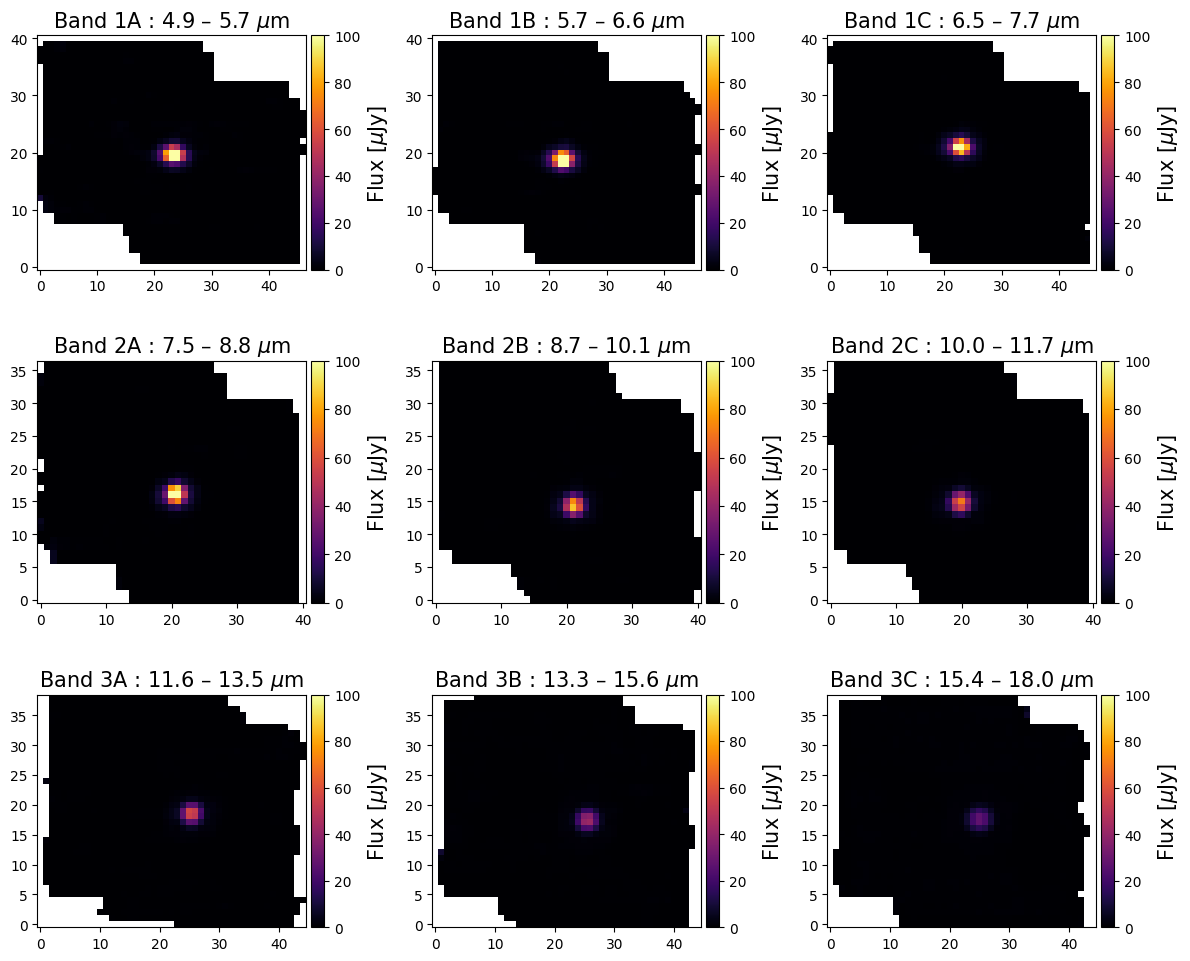

In [5]:
# Plot the median slice for each cube
fig = plt.figure(figsize = (12,10), tight_layout = False)
for ch in range(len(bands)):
    ax = fig.add_subplot(3, 3, 1+ch)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size = "5%", pad = 0.05)
    median_image = np.nanmedian(science_cube[bands[ch]], axis=0)
    im = ax.imshow(median_image, cmap="inferno",origin='lower', vmin=0, vmax=1e2)#norm=LogNorm(vmin=1e-1, vmax=1e5))
    cbar = fig.colorbar(im, cax = cax, orientation = "vertical")
    cbar.set_label("Flux [$\mu$Jy]", color="black", size=fs)
    ax.set_title(f"Band {bands[ch]} : {np.min(science_wave[bands[ch]]):.1f} – {np.max(science_wave[bands[ch]]):.1f} $\mu$m", 
                 fontsize=fs)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.tight_layout()
plt.show()

## 2. Molecular mapping.

In [6]:
# Model
wavelength_model, flux_model = load_spectrum(path_model+f'spect_{temp_pl}K_logg{logg_pl}_met{met_pl}_CO{co_pl}_fsed{fsed_pl}.h5',
                                             path_wave='/Users/mmalin/Models_spectra/ExoREM_2026/wavenumber.h5', 
                                             Rp=Rp, dstar=dstar, degraded=True, res=res)


# Correlation analysis
cc_map = {}
for band in bands:
    f1 = interpolate.interp1d(wavelength_model,flux_model, fill_value="extrapolate" )
    spectre_model_interp = f1(science_wave[band])
    cc_map[band] = compute_cc_maps_coef(science_cube[band], spectre_model_interp, sigma)

pos_planet_b = {}
for band in bands:
    pos = np.where(cc_map[band]==np.nanmax(cc_map[band]))
    pos_planet_b[band] = [pos[1][0], pos[0][0]]

SNR_model, SNR_1px, cc_max = {}, {}, {}
for band in bands:
    pos_planet = int(np.around(pos_planet_b[band][0], 0)), int(np.around(pos_planet_b[band][1], 0))
    SNR_model[band], SNR_1px[band], cc_max[band] = SNR_profil_cc(cc_map[band], pos_planet)

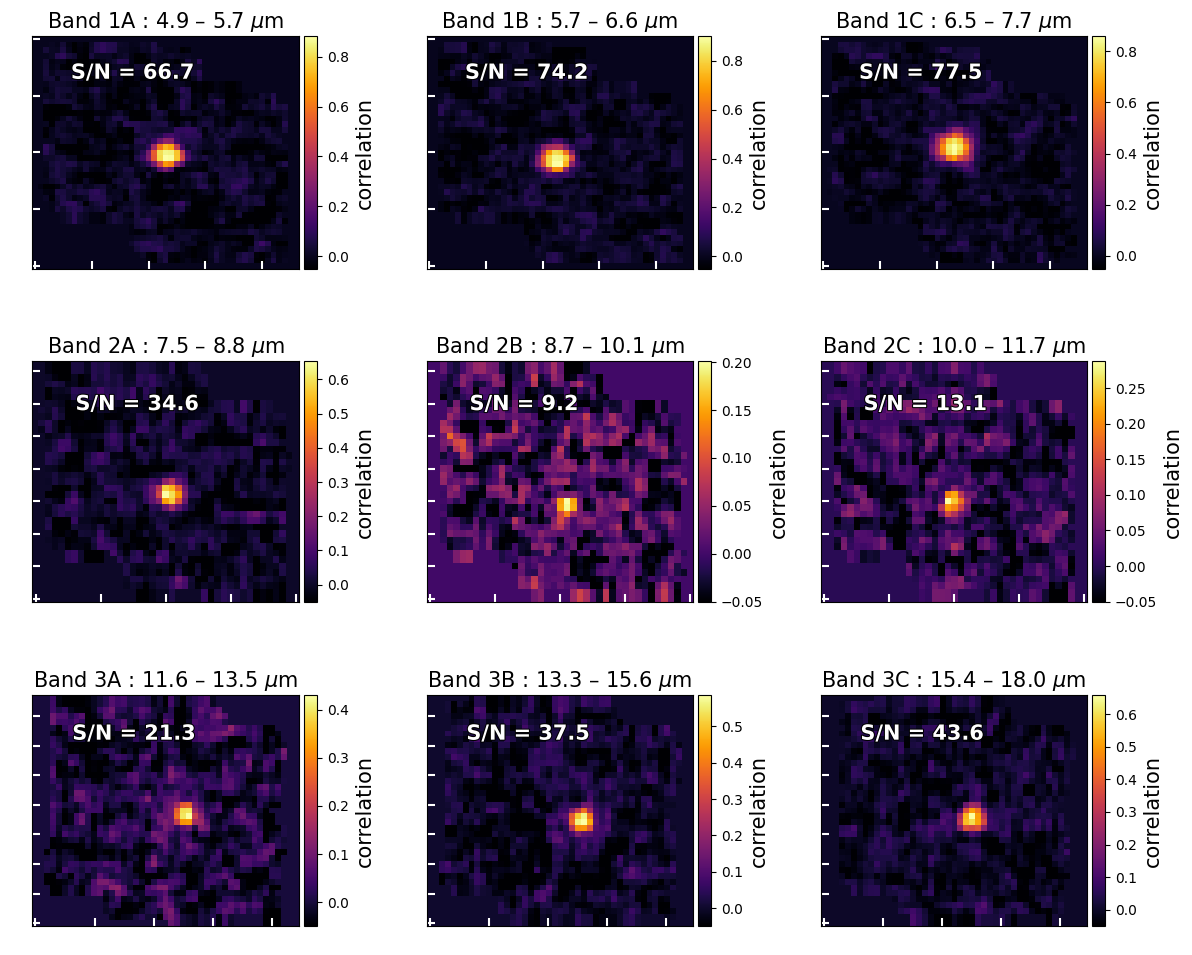

In [7]:
# Plot the correlation maps
fig = plt.figure(figsize = (12,10), tight_layout = False)
for ch in range(len(bands)):
    ax = fig.add_subplot(3, 3, 1+ch)
    divider = make_axes_locatable(ax)
    cc_map_nonan = np.nan_to_num(cc_map[bands[ch]], nan=0.0)
    cax = divider.append_axes("right", size = "5%", pad = 0.05)
    im = ax.imshow(cc_map_nonan, cmap="inferno",origin='lower', vmin=-0.05,vmax=np.nanmax(cc_map[bands[ch]]))
    cbar = fig.colorbar(im, cax=cax, orientation="vertical")
    cbar.set_label("correlation", color="black", size=fs)
    ax.set_title(f"Band {bands[ch]} : {np.min(science_wave[bands[ch]]):.1f} – {np.max(science_wave[bands[ch]]):.1f} $\mu$m", fontsize=fs)
    ax.text(5,np.shape(cc_map[bands[ch]])[0]-8, f" S/N = {SNR_model[bands[ch]]:.1f}",fontsize = fs,color='white', fontweight='bold',
            path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])
    ax.tick_params(axis='both', colors='white', direction='in', length=6, width=1.5,  which='both')  
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.tight_layout()
plt.savefig(output_dir+f'{name_system}_cc_maps_{temp_pl}K.pdf')
plt.show()

## 3. Correlation with molecular templates

In [8]:
# Load and plot ExoREM molecular spectra 
model = f'spectra_YGP_{temp}K_logg4.0_met1.00_CO0.50.dat'

# Column and molecule names
name_column = ["wavenumber", "spectral_flux", "spectral_flux_clear", "spectral_flux_full_cover",
               "spectral_radiosity", "spectral_radiosity_thermal", "spectral_radiosity_cia_rayleigh",
               "spectral_radiosity_CH4", "spectral_radiosity_CO", "spectral_radiosity_CO2", "spectral_radiosity_FeH",
               "spectral_radiosity_H2O", "spectral_radiosity_H2S", "spectral_radiosity_HCN", "spectral_radiosity_K",
               "spectral_radiosity_Na", "spectral_radiosity_NH3", "spectral_radiosity_PH3", "spectral_radiosity_TiO",
               "spectral_radiosity_VO"]

molec_names = ["Flux", "Flux thermal", "CIA", "CH4", "CO", "CO2", "FeH", "H2O",
               "H2S", "HCN", "K", "Na", "NH3", "PH3", "TiO", "VO"]

# Colors and colormaps
molec_colors = {
    "Flux":"black","Flux thermal":"black","CIA":"black","CH4":"indigo","CO":"red","CO2":"dodgerblue",
    "FeH":"orange","H2O":"cornflowerblue","H2S":"gold","HCN":"darkorange","K":"teal","Na":"pink",
    "NH3":"green","PH3":"magenta","TiO":"grey","VO":"darkred"}

color_maps = {
    "Flux":"inferno","Flux thermal":"inferno","CIA":"viridis","CH4":"Purples_r","CO":"Reds_r",
    "CO2":"GnBu_r","FeH":"YlOrBr_r","H2O":"Blues_r","H2S":"YlOrRd_r","HCN":"Oranges_r",
    "K":"RdPu_r","Na":"PuBu_r","NH3":"Greens_r","PH3":"PuRd_r","TiO":"OrRd_r","VO":"Greys_r"}

# Load spectra for each molecule
wave_molec, flux_molec = {}, {}
for idx, m in zip(range(4, len(name_column)), molec_names):
    wave_molec[m], flux_molec[m] = load_spectra_molec(path_molec + model, idx,  Rp, dstar,
                                                       degraded=True, res=res, plot=False, savefig=False)

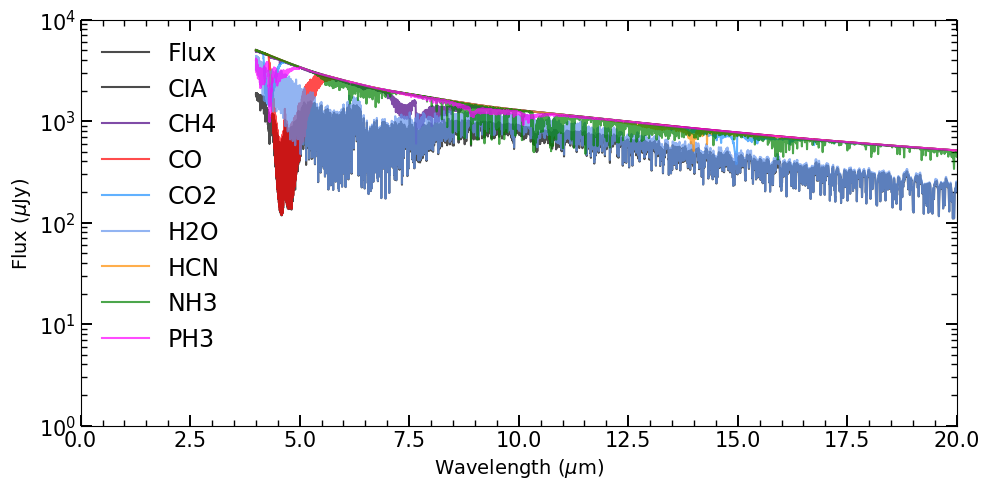

In [9]:
# Plot all molecular templates
fig, ax = plt.subplots(figsize=(10, 5))

molecules = ['Flux', 'CIA', r'CH4', 'CO', r'CO2', r'H2O','HCN', r'NH3', r'PH3']
for m in molecules:
    ax.plot(wave_molec[m],flux_molec[m], label=m,alpha=0.7,color=molec_colors[m])

ax.set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
ax.set_ylabel(r'Flux ($\mu$Jy)', fontsize=14)

ax.set_yscale('log')
ax.set_ylim(1, 1e4)
ax.set_xlim(0, 20)

ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.tick_params(which="major", length=8, width=1.4, labelsize=fs)
ax.tick_params(which="minor", length=4, width=1.0)
ax.minorticks_on()

ax.legend(frameon=False, fontsize=fs+2)
fig.tight_layout()

fig.savefig(
    f"{output_dir}/ExoREM_molec_templates_{temp}K.pdf",
    bbox_inches="tight",
    pad_inches=0.1)

plt.show()


Flux


  0%|          | 0/9 [00:00<?, ?it/s]

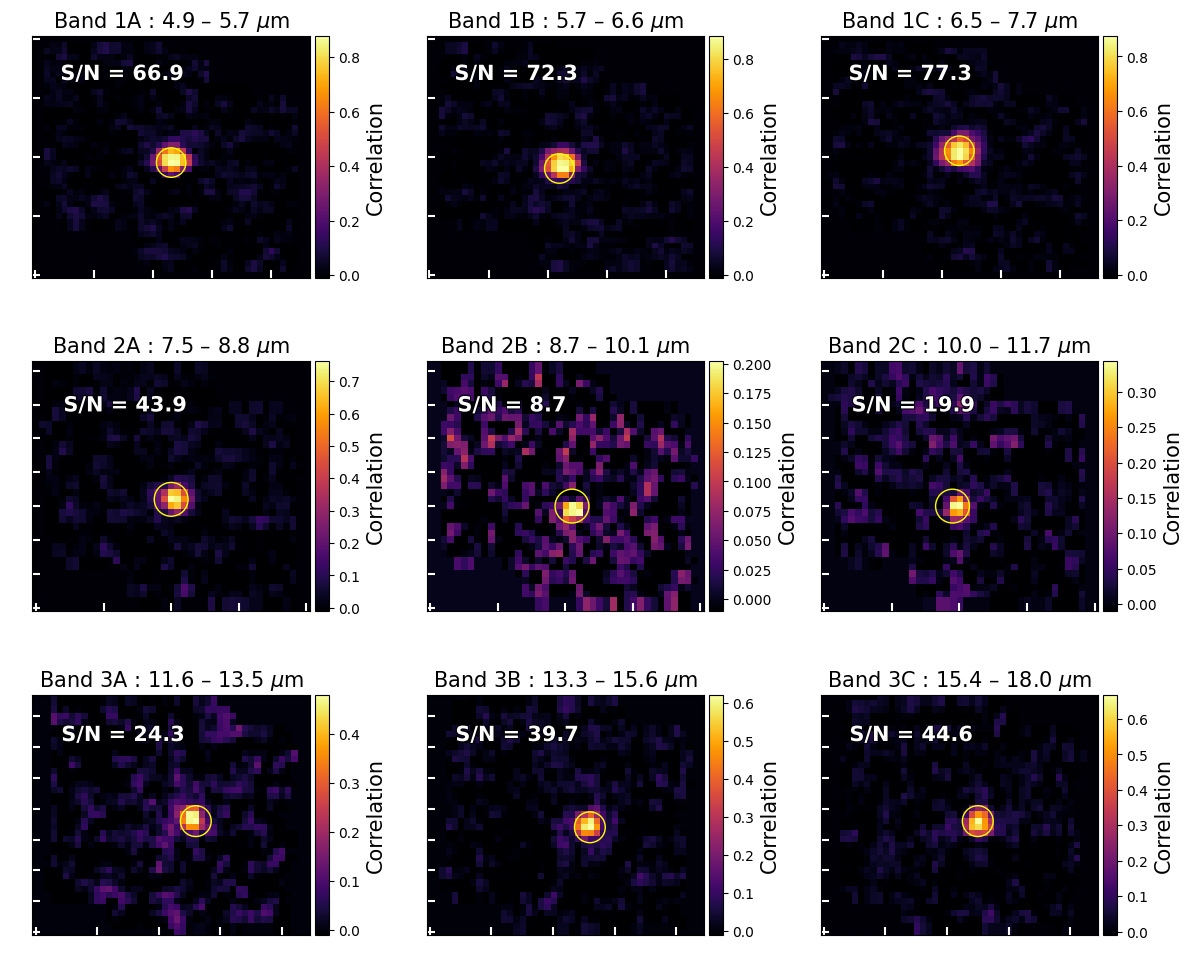

Flux thermal


  0%|          | 0/9 [00:00<?, ?it/s]

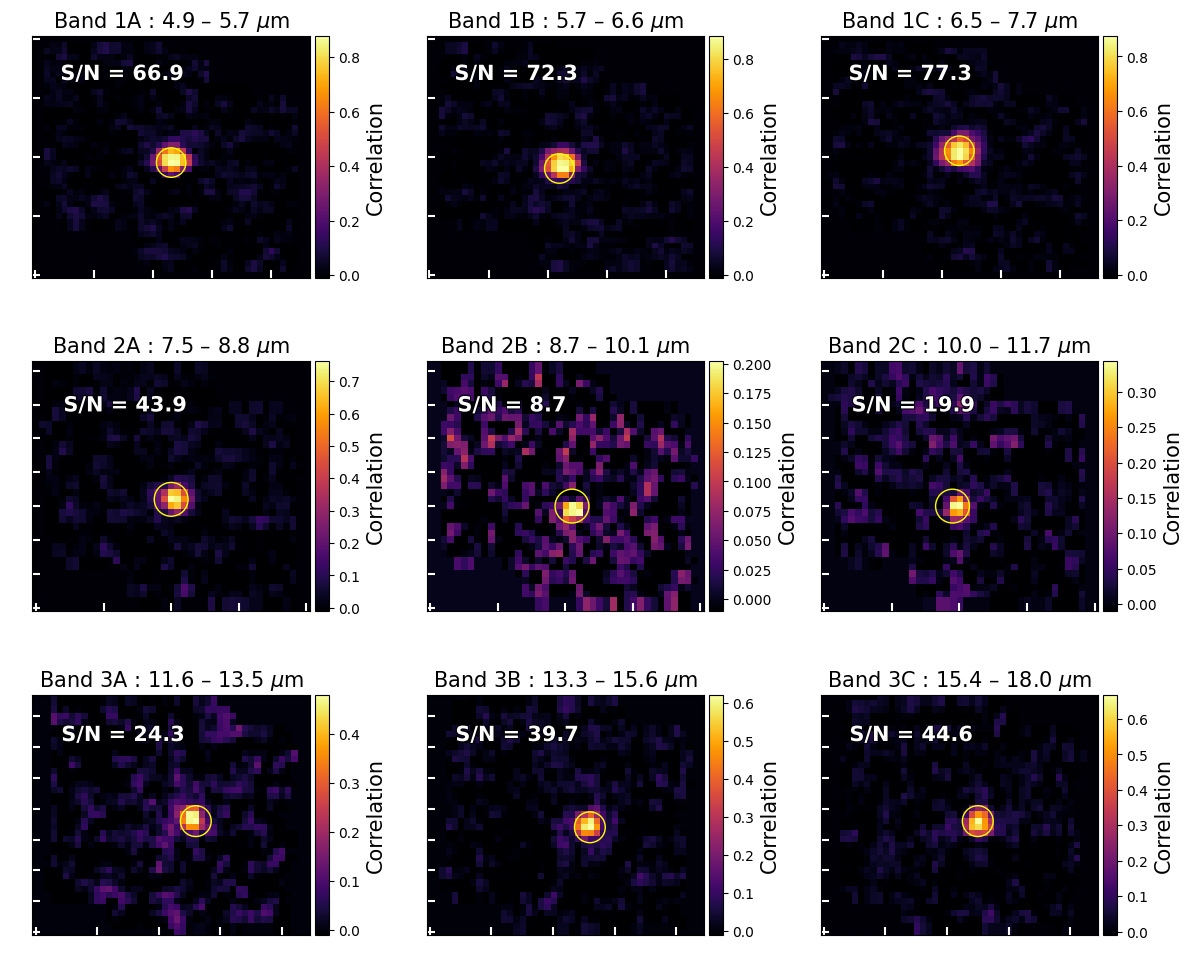

CIA


  0%|          | 0/9 [00:00<?, ?it/s]

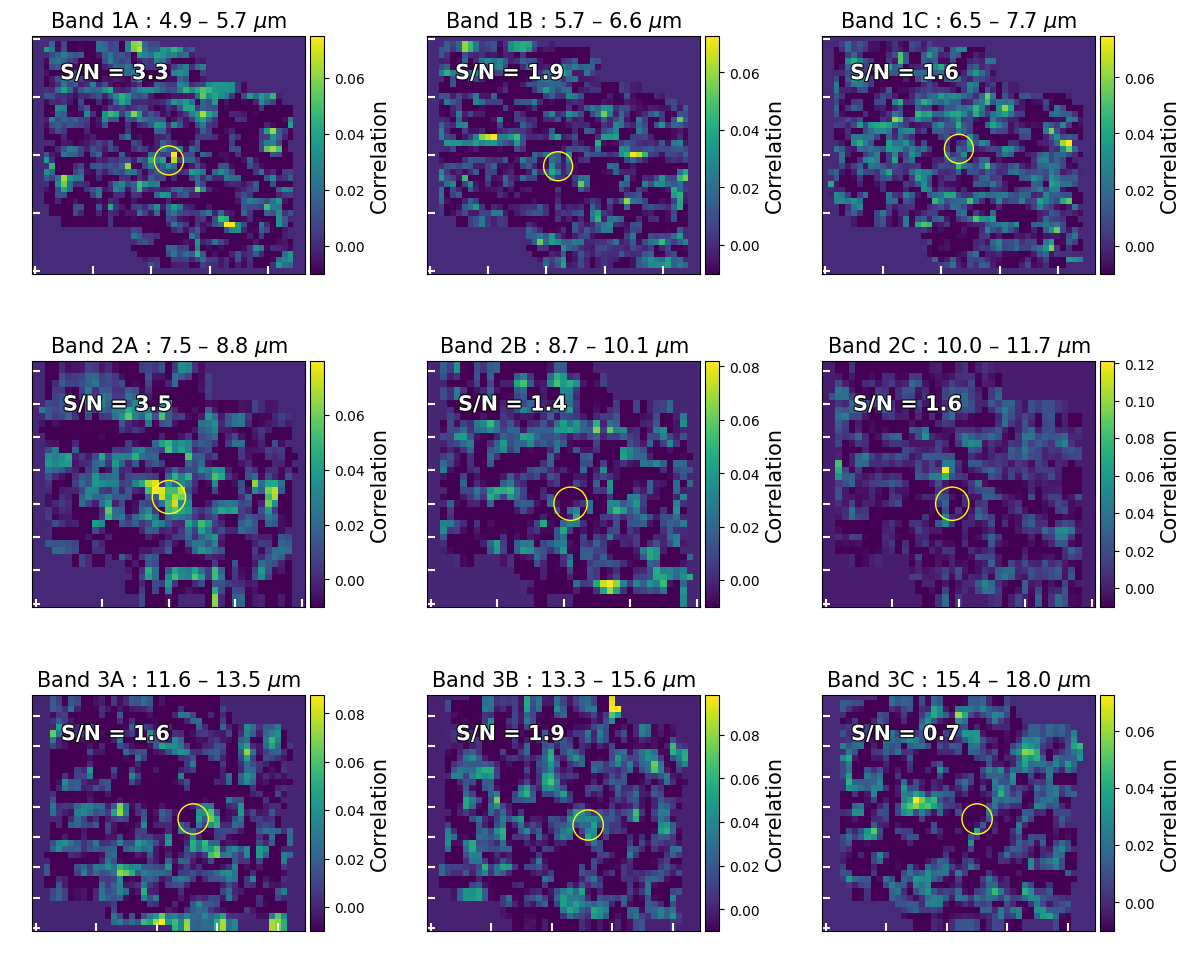

CH4


  0%|          | 0/9 [00:00<?, ?it/s]

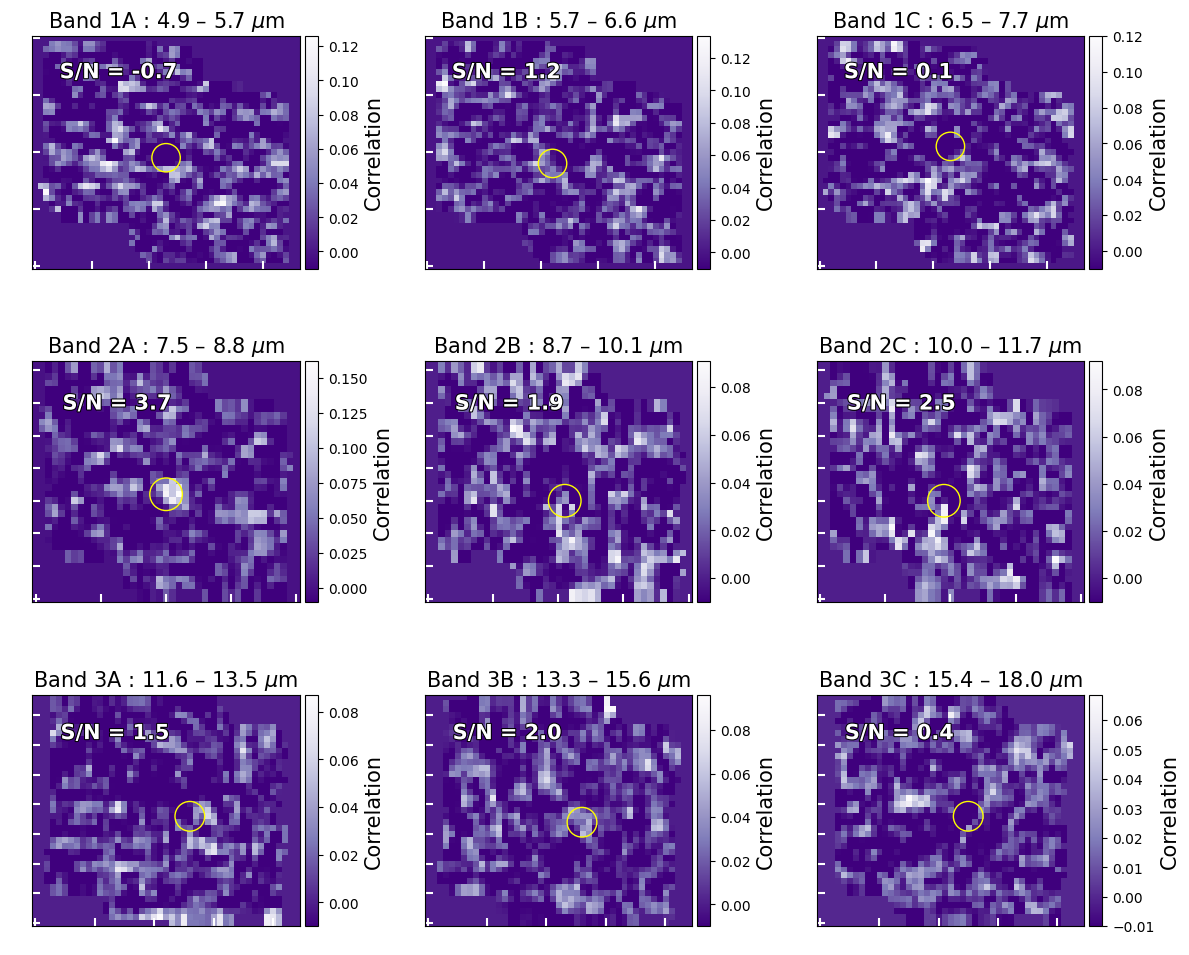

CO


  0%|          | 0/9 [00:00<?, ?it/s]

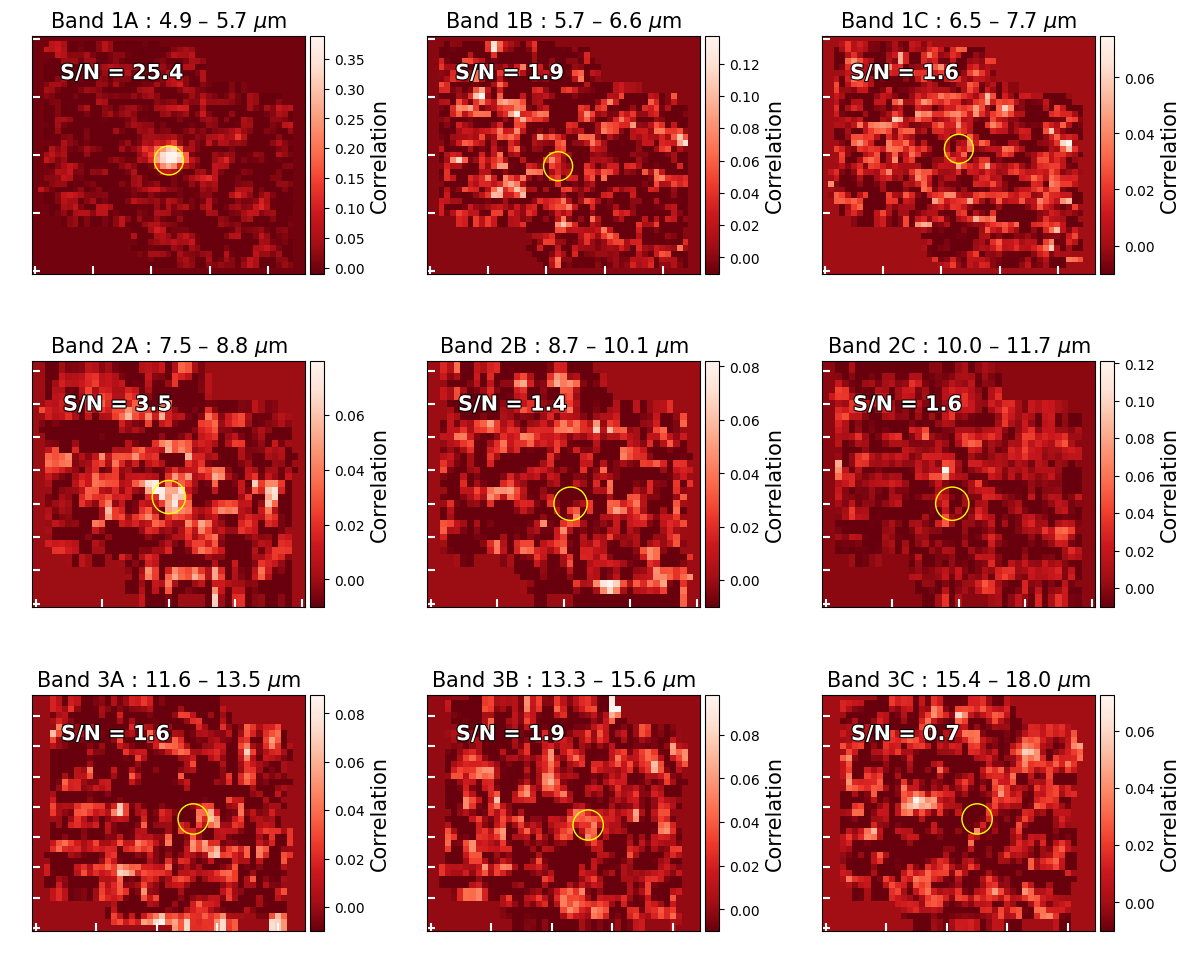

CO2


  0%|          | 0/9 [00:00<?, ?it/s]

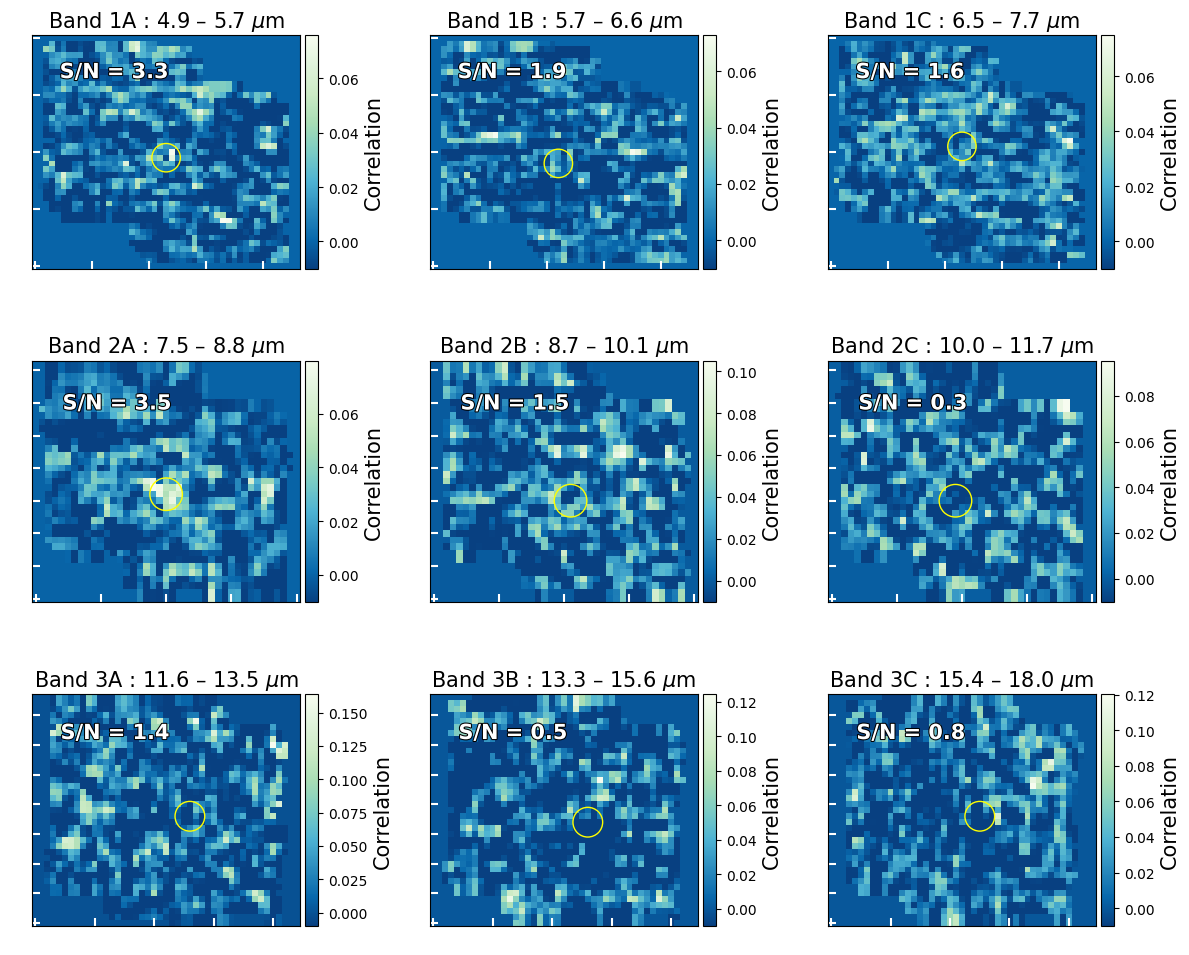

FeH


  0%|          | 0/9 [00:00<?, ?it/s]

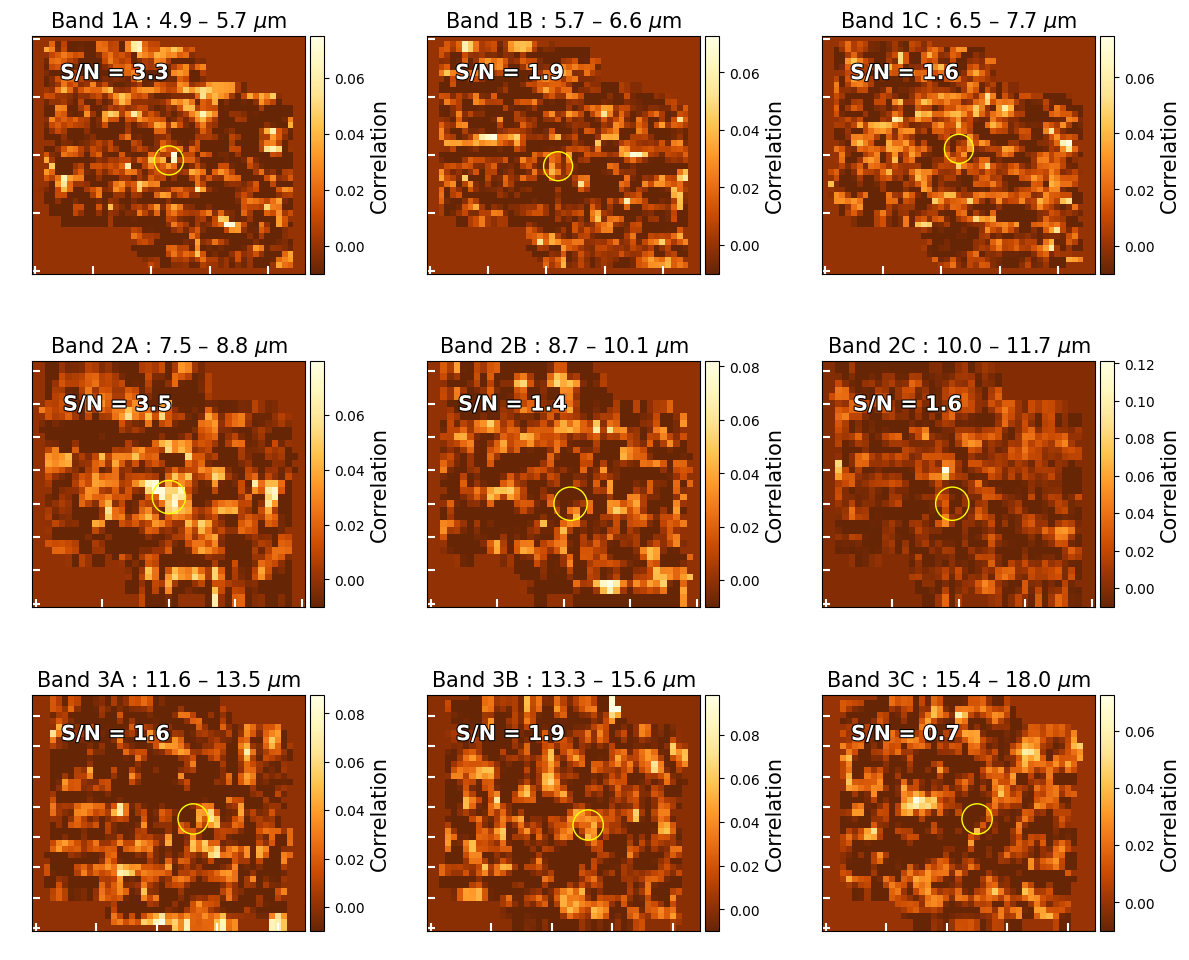

H2O


  0%|          | 0/9 [00:00<?, ?it/s]

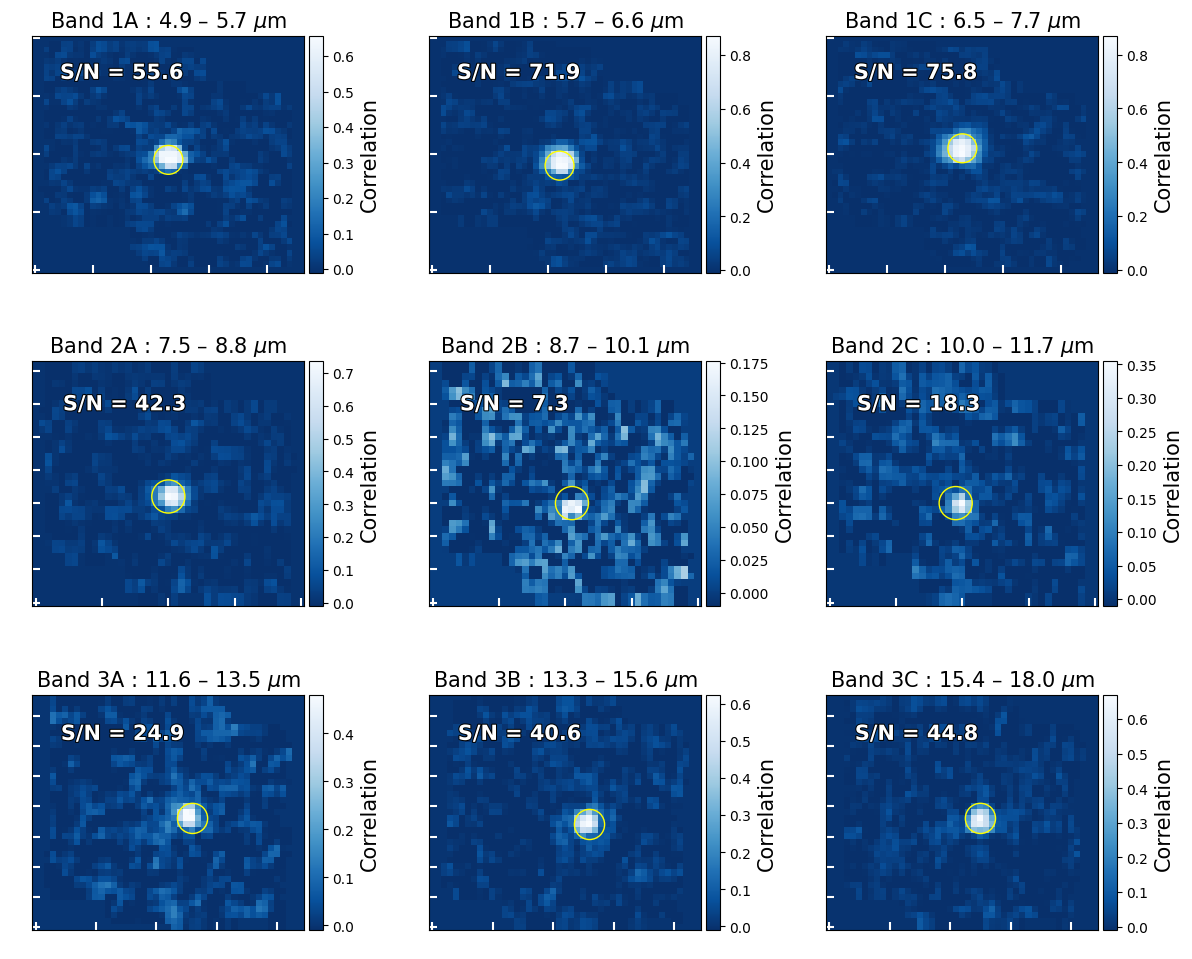

H2S


  0%|          | 0/9 [00:00<?, ?it/s]

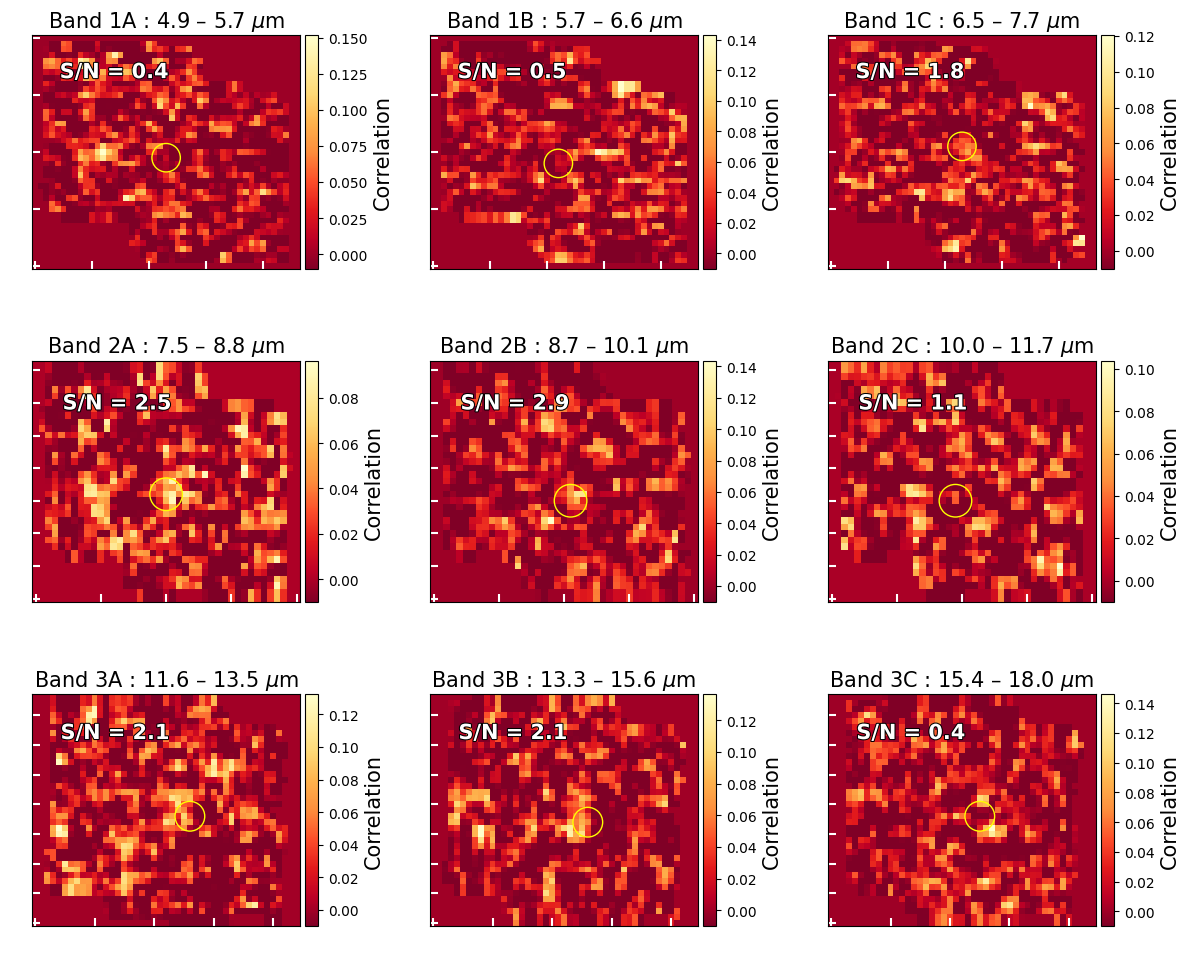

HCN


  0%|          | 0/9 [00:00<?, ?it/s]

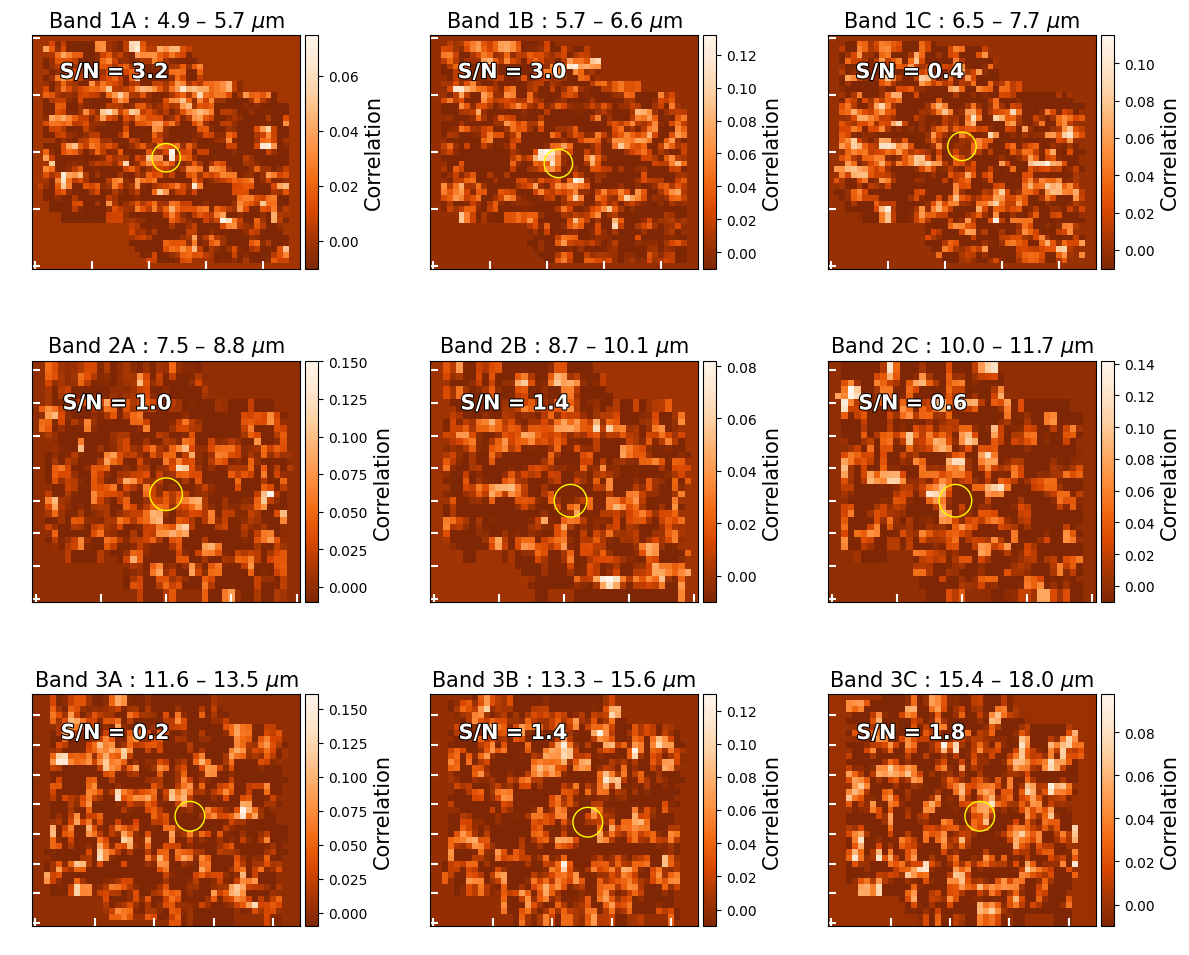

K


  0%|          | 0/9 [00:00<?, ?it/s]

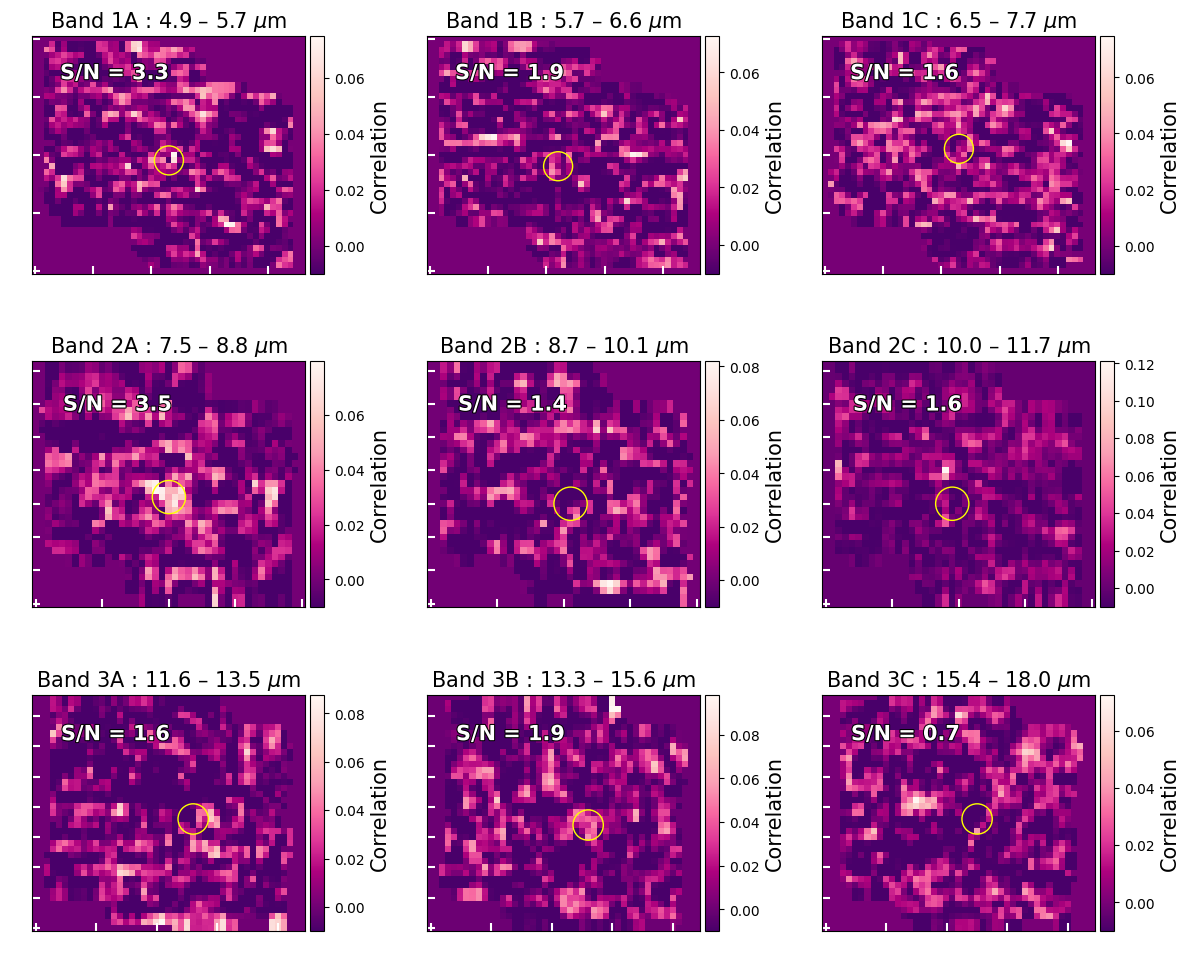

Na


  0%|          | 0/9 [00:00<?, ?it/s]

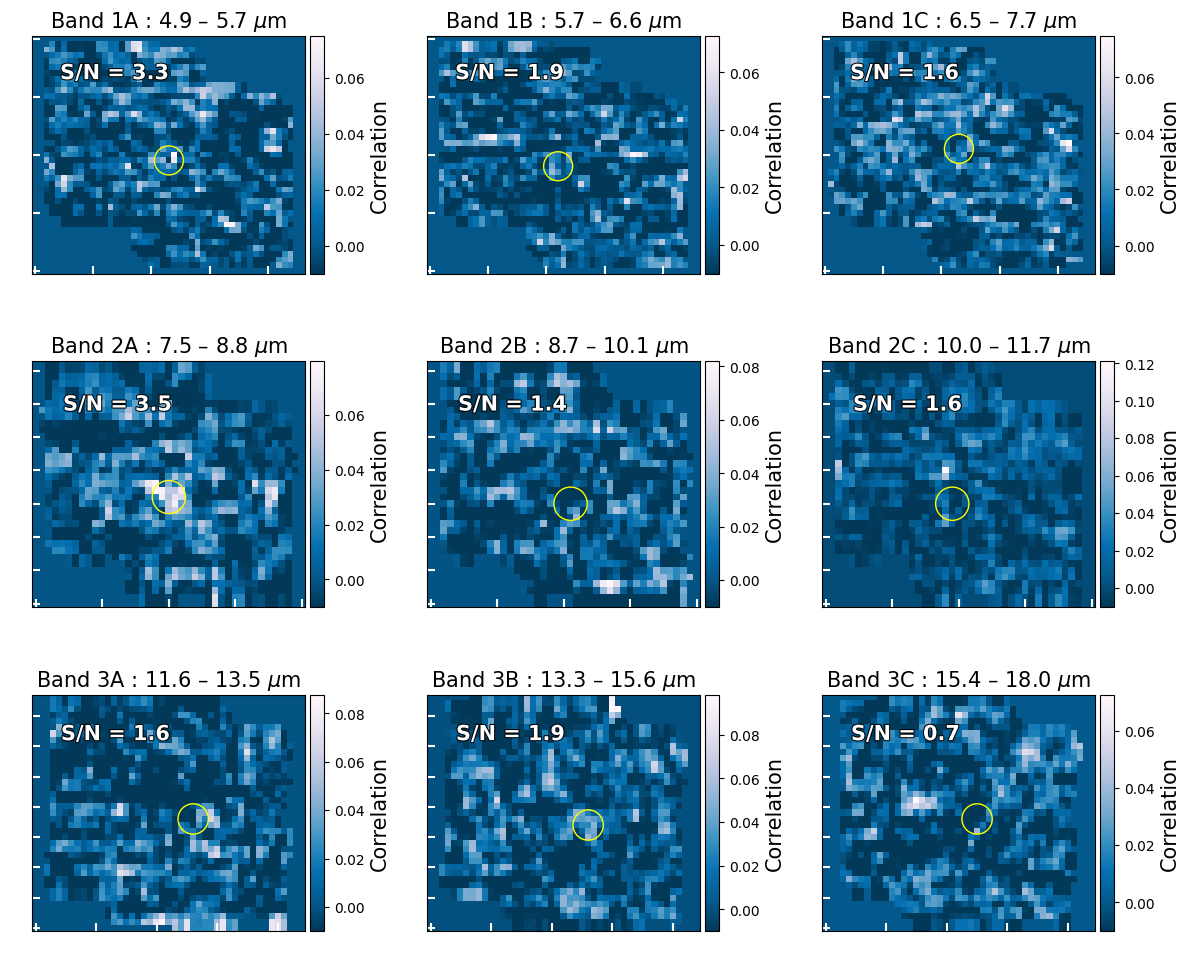

NH3


  0%|          | 0/9 [00:00<?, ?it/s]

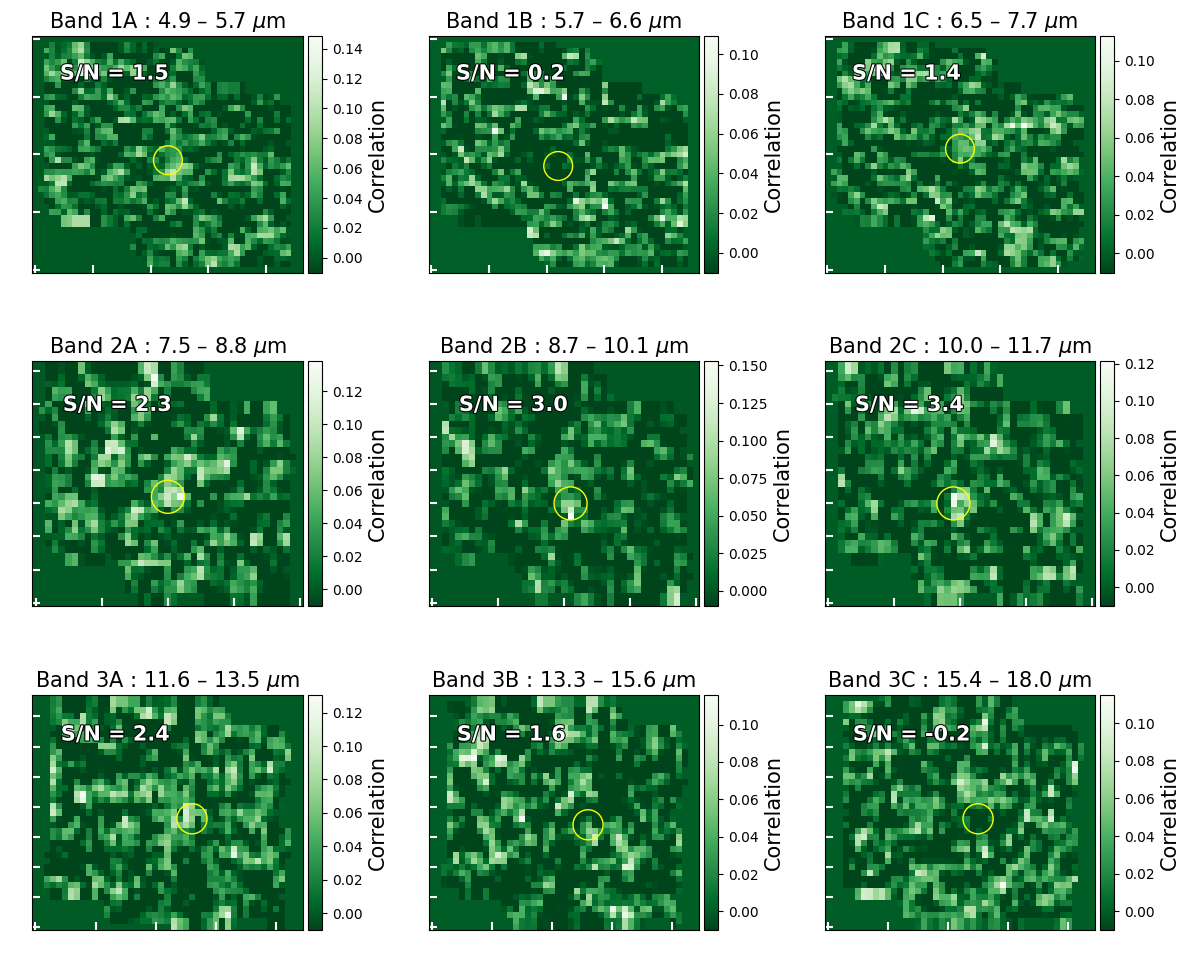

PH3


  0%|          | 0/9 [00:00<?, ?it/s]

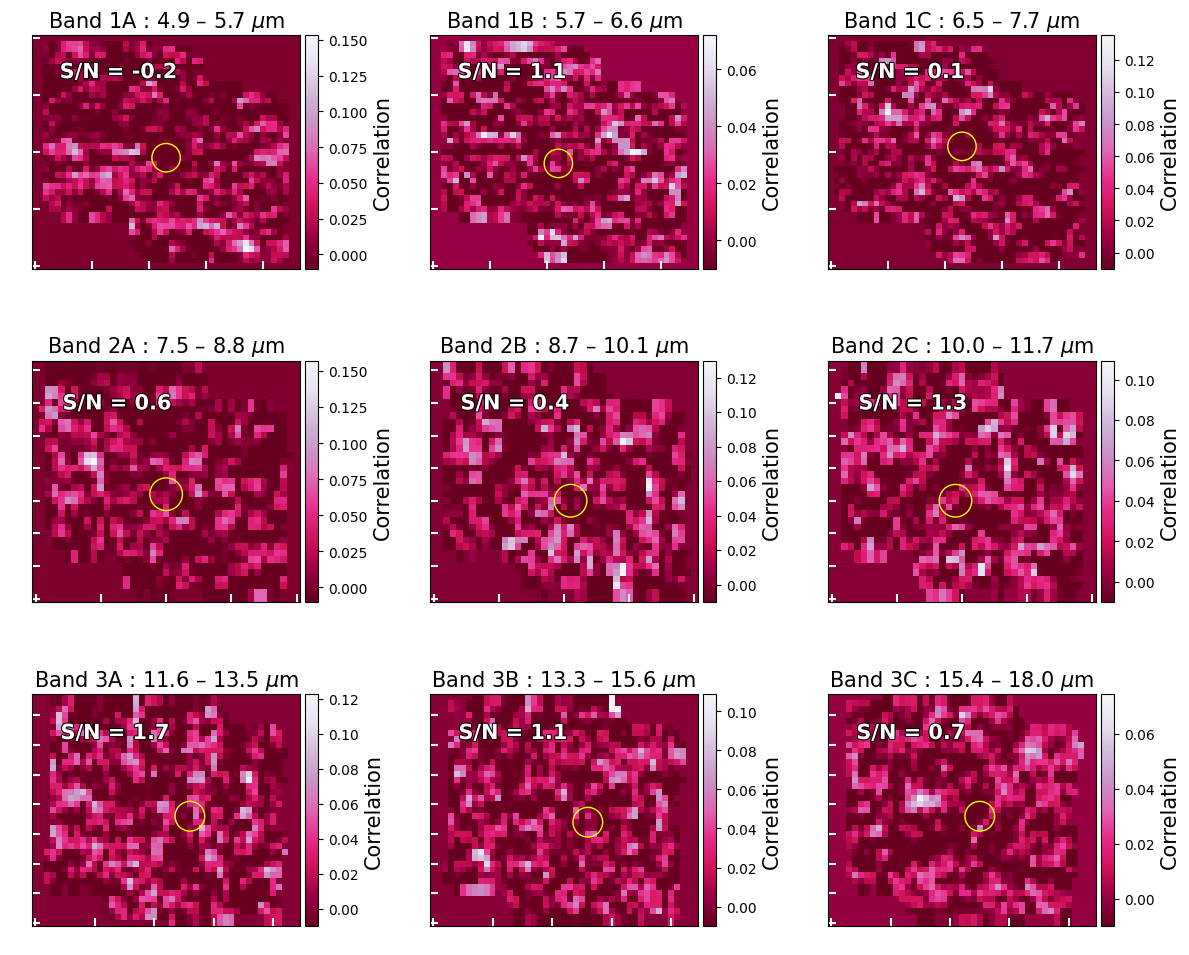

TiO


  0%|          | 0/9 [00:00<?, ?it/s]

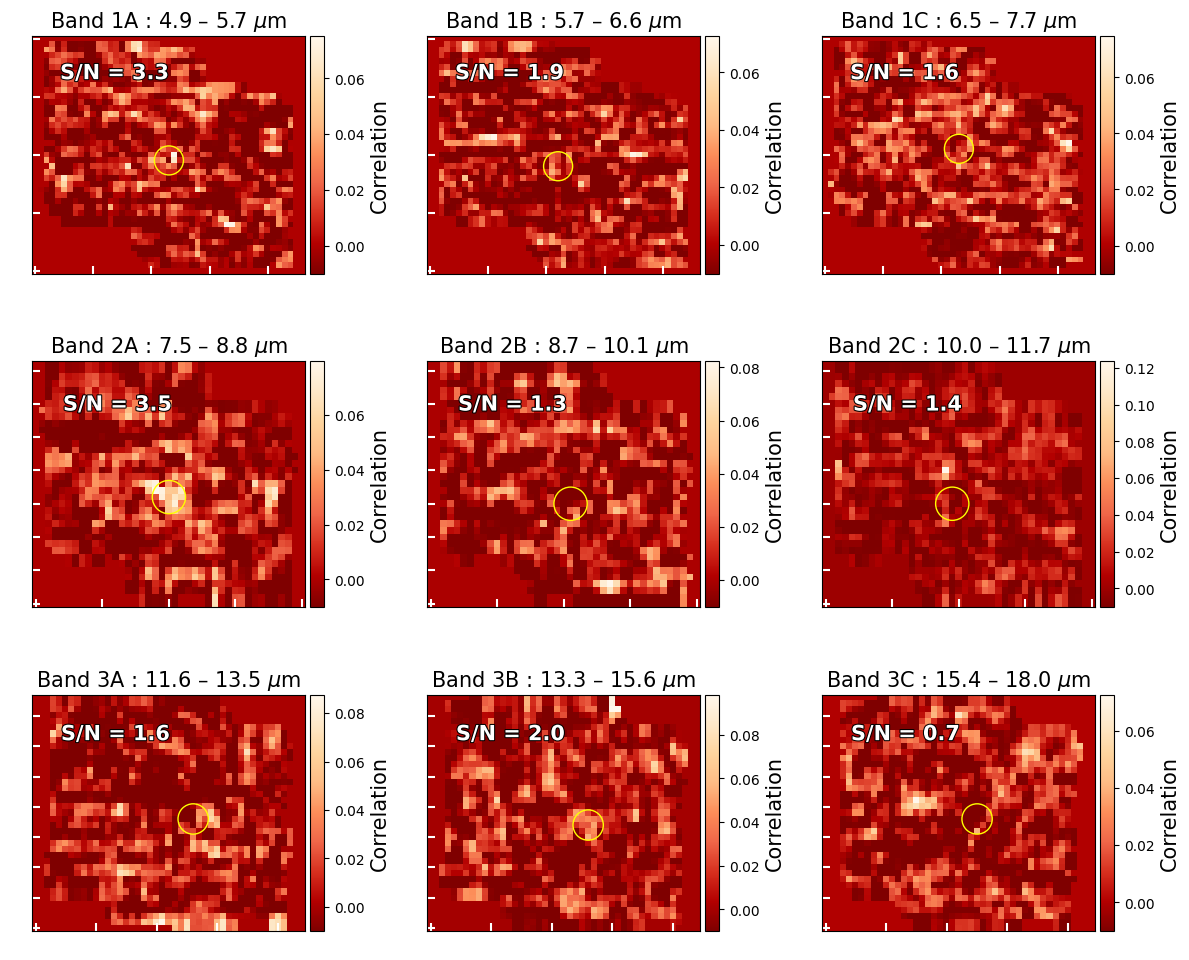

VO


  0%|          | 0/9 [00:00<?, ?it/s]

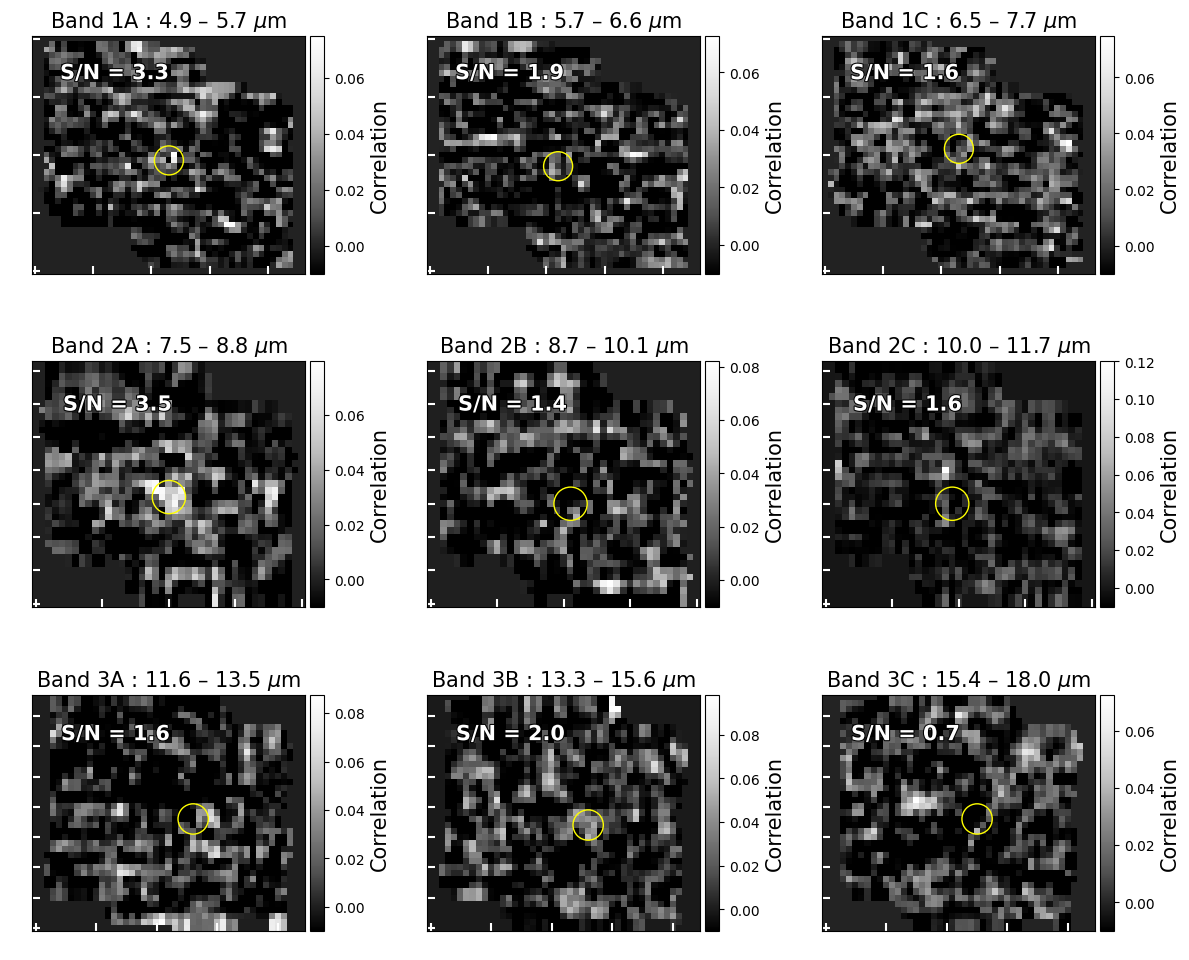

In [10]:
cc_maps_all = {}
for m in molec_names:
    print(f"{m}")
    # Measure correlation maps
    cc_maps_molec = {}
    for band in bands :
        flux_molec_interp = interpolate.interp1d(wave_molec[m], flux_molec[m], fill_value="extrapolate" )(science_wave[band])
        cc_maps_molec[band] = compute_cc_maps_coef(science_cube[band], flux_molec_interp, sigma)
    cc_maps_all[m] = cc_maps_molec
    # Measure the signal-to noie
    SN_pl_b = {}
    for band in bands:
        SN_pl_b[band], __, __ = SNR_profil_cc(cc_maps_molec[band], (int(np.around(pos_planet_b[band][0], 0)), int(np.around(pos_planet_b[band][1], 0))))

    # Plot the correlations maps for each band
    fig = plt.figure(figsize=(12, 10), tight_layout=False)
    for ch in tqdm(range(len(bands))):
        band = bands[ch]
        ax = fig.add_subplot(3, 3, 1 + ch)
        divider = make_axes_locatable(ax)
        cc_map_nonan = np.nan_to_num(cc_maps_molec[band], nan=0.0)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        im = ax.imshow(cc_map_nonan,cmap=color_maps[m], origin='lower',vmin=-0.01,vmax=np.nanmax(cc_maps_molec[band]))
        cbar = fig.colorbar(im, cax=cax, orientation="vertical")
        cbar.set_label("Correlation", size=fs, color='black')
        ax.set_title(f"Band {band} : {np.min(science_wave[band]):.1f} – {np.max(science_wave[band]):.1f} $\mu$m", fontsize=fs)
        ax.text(3, cc_maps_molec[band].shape[0] - 8, f" S/N = {SN_pl_b[band]:.1f}",fontsize=fs,
                color='white',fontweight='bold',path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'), path_effects.Normal()] )
    
        ax.add_artist(plt.Circle(pos_planet_b[band], 2.5, fill=False, color="yellow"))  # Planet position circle
        ax.tick_params(axis='both', colors='white', direction='in', length=6, width=1.5, which='both')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.tight_layout()
    plt.savefig(output_dir + f'{name_system}_cc_maps_{temp}K_{m}.png', bbox_inches='tight', pad_inches=0.1)
    plt.show()


## 4. Final plot

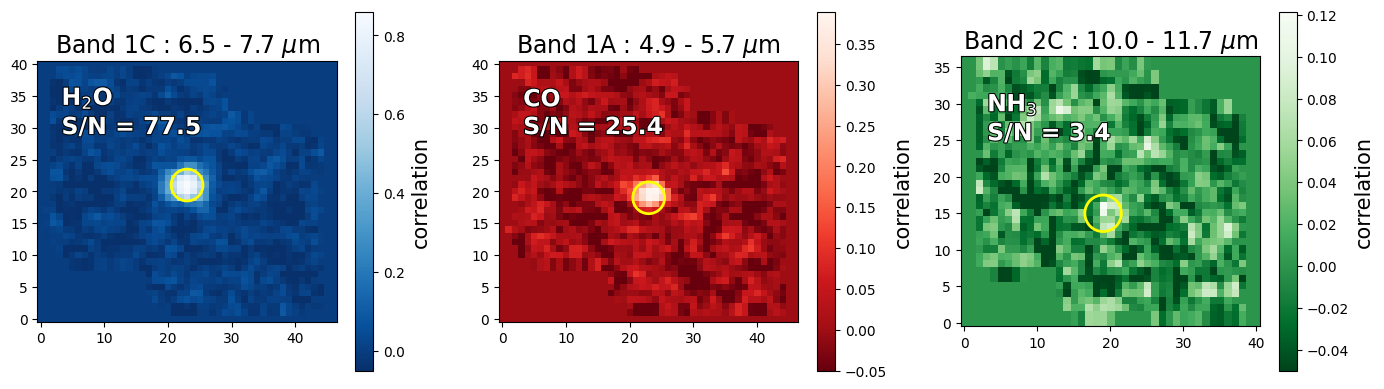

In [11]:
select_bands = ['1C', '1A', '2C']
molecs = ['H2O', 'CO', 'NH3']
molecs_nameplot = ['H$_2$O', 'CO', 'NH$_3$']

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for idx, (band, m) in enumerate(zip(select_bands, molecs)):
    
    # --- choose which CC map to plot ---
    if idx == 0:
        cc_map_used = cc_map[band]
    else:
        cc_map_used = cc_maps_all[m][band]

    SN_pl_b[band], __, __ = SNR_profil_cc(cc_map_used, pos_planet_b[band])
    cc_map_nonan = np.nan_to_num(cc_map_used, nan=0.0)

    im = ax[idx].imshow(cc_map_nonan, origin='lower', cmap=color_maps[m], vmin=-0.05)
    ax[idx].set_title(f"Band {band} : {np.min(science_wave[band]):.1f} - {np.max(science_wave[band]):.1f} $\mu$m",
                      fontsize=fs+2)
    ax[idx].add_artist(plt.Circle(pos_planet_b[band], 2.5, fill=False,color="yellow", linewidth=2))

    cbar = fig.colorbar(im, ax=ax[idx], orientation='vertical')
    cbar.set_label("correlation", color="black", size=fs)

    ax[idx].text(2, np.shape(cc_map_used)[0] - 12, f" {molecs_nameplot[idx]} \n S/N = {SN_pl_b[band]:.1f}",
                 fontsize=fs+2,color='white',fontweight='bold',
                 path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])

plt.tight_layout()
plt.savefig(output_dir + f'{name_system}_detected_molec{temp}K.pdf')
plt.show()
